In [37]:
import scipy.io as sio
GOOGLE_COLAB = True
path = ""
if GOOGLE_COLAB:
    from google.colab import drive, files
    drive.mount('/content/drive/')
    path = "/content/drive/My Drive/ML AI/"

dataset = path + "data.mat"

test_image=path+"Testimage3.jpeg"
mat_contents = sio.loadmat(dataset)
mat_contents
images = mat_contents['images']
label = mat_contents['C']
images.shape

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


(50, 3072)

If you can see the shape of images in 'data.mat' then your data has been read.

In [38]:
import numpy as np
images= np.transpose(images)

In [39]:
images.shape
im = np.reshape(images, [ 32, 32, 3, -1], order="F")

(32, 32, 3)


(32, 32, 3)

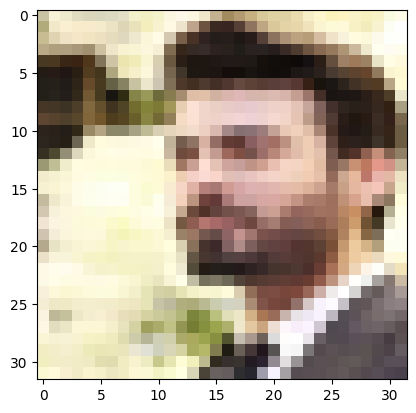

In [40]:
from matplotlib import pyplot as plt

plt.imshow(im[:,:,:,40])
print(im[:,:,:,0].shape)
a= im[:,:,:,40]
plt.imshow(a)
a.shape

Now upload a test image into your drive it can be you own image

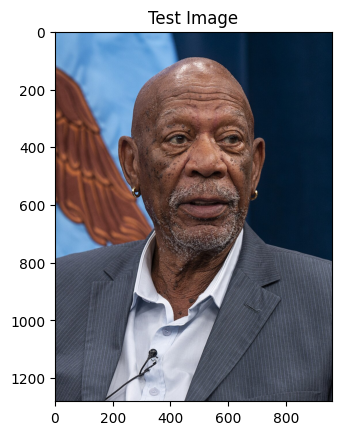

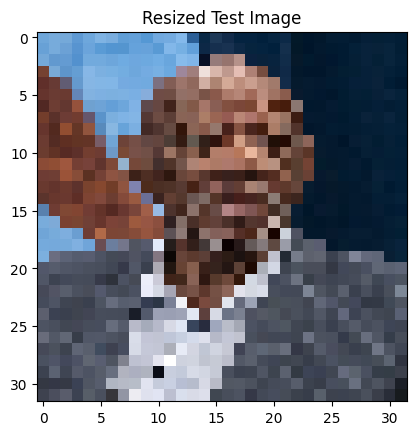


 Shape of final reshaped test image:  (3072,)


In [41]:
from scipy import misc
import cv2
from math import sqrt
from numpy import ndarray


test = plt.imread(test_image)
plt.title("Test Image")
plt.imshow(test)
plt.show()

# Resizing image

test2 = cv2.resize(test, dsize=(32, 32), interpolation=cv2.INTER_CUBIC)
plt.title("Resized Test Image")
plt.imshow(test2)
plt.show()


# Reshaping image
test3 = np.reshape(test2,[-1], order="F")
print("\n Shape of final reshaped test image: ", test3.shape)

In [42]:
# Eucleadian distance

test3 = test3 / 255.0
im = im / 255.0
dist=np.zeros((1,im.shape[3]))
for i in range(50):
  G = im[:,:,:,i]
  G = np.reshape(G,[-1], order="F")
  temp = test3 - G
  dist[0,i]= np.sum(np.dot(temp.T, temp))
dist


array([[532.55763168, 282.38665129, 350.48064591, 664.36510573,
        203.37539408, 868.50662053, 359.59029604, 380.9735025 ,
        364.79514033, 360.55444829, 640.73064206, 397.24076894,
        356.7761015 , 399.98851211, 293.20418301, 501.36661284,
        702.57897732, 497.6305421 , 568.01339485, 354.36009227,
        256.07038831, 399.62528258, 363.02991157, 369.1628143 ,
        861.36244521, 737.49584006, 627.64884275, 582.35992311,
        441.6       , 523.09067282, 415.30308343, 291.29953095,
        321.1285198 , 437.36109189, 273.48422914, 725.86834295,
        810.00212226, 347.83143406, 461.54828143, 430.28370627,
        617.03018839, 368.05339485, 307.71910804, 459.40436755,
        596.65862361, 392.13482507, 559.91044983, 669.4480892 ,
        420.27144944, 396.50162245]])

In this Block you need to fill the code for 1-NN.

Minimum distance:  203.37539407920025
Minimum value is at index no  4 of the dataset



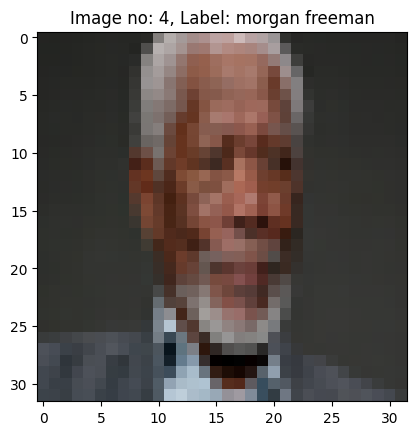

In [43]:
# 1NN

N1 = np.min(dist)
print("Minimum distance: ", N1)
pos1 = np.where(dist==N1)
pos1 = pos1[1][0]
print("Minimum value is at index no ", str(pos1), "of the dataset\n")

plt.title("Image no: " + str(pos1) + ", Label: " + str(label[pos1][0][0]))
plt.imshow(im[:,:,:,pos1])
plt.show()



3 NN Code


1 Minimum distance:  203.37539407920025
2 Minimum distance:  256.0703883121876
3 Minimum distance:  273.48422914263745


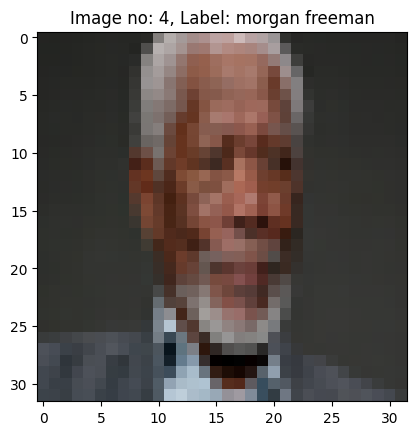

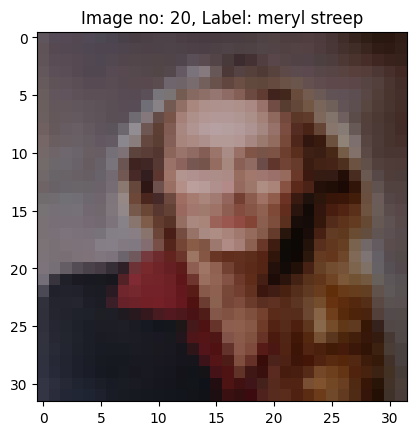

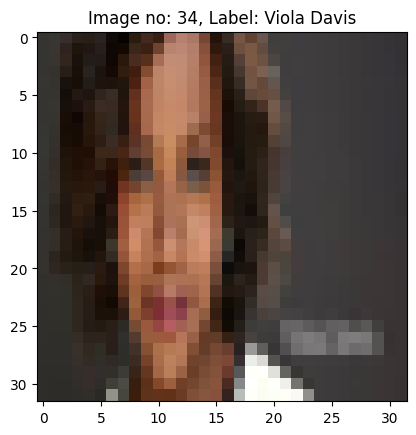


As per majority voting scheme for k=3, test image mostly resembles:  morgan freeman


In [44]:
# 3NN Code

sort_dist=np.sort(dist.flatten())
N3 = sort_dist[:3]
pos3 = [[] for _ in range(3)]
for i in range(3):
  print(i+1,"Minimum distance: ",N3[i])
  pos3[i] = np.where(dist==N3[i])
pos3=[pos3[i][1][0] for i in range(3)]

for i in range (3):
  plt.title("Image no: " + str(pos3[i]) + ", Label: " + str(label[pos3[i]][0][0]))
  plt.imshow(im[:,:,:,pos3[i]])
  plt.show()

from collections import Counter
def knn(pos, k):
  nearest_labels = [str(label[i][0]) for i in pos]
  most_common_label = Counter(nearest_labels).most_common(1)[0][0]
  return most_common_label

majority_label_3nn = knn(pos3, 3)
majority_label_3nn = majority_label_3nn.strip("[]'\"")
print("\nAs per majority voting scheme for k=3, test image mostly resembles: ", majority_label_3nn)

5 NN

1 Minimum distance:  203.37539407920025
2 Minimum distance:  256.0703883121876
3 Minimum distance:  273.48422914263745
4 Minimum distance:  282.3866512879662
5 Minimum distance:  291.2995309496347


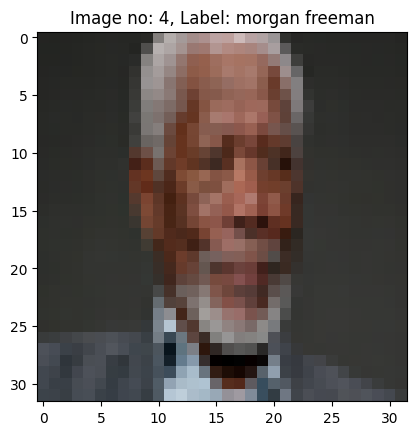

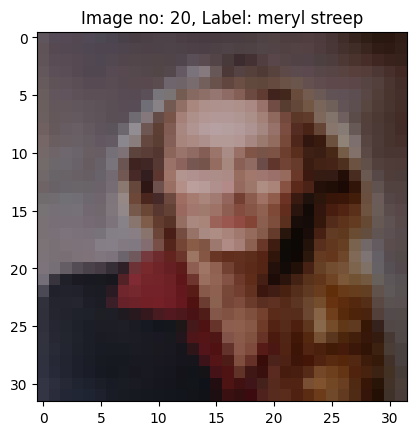

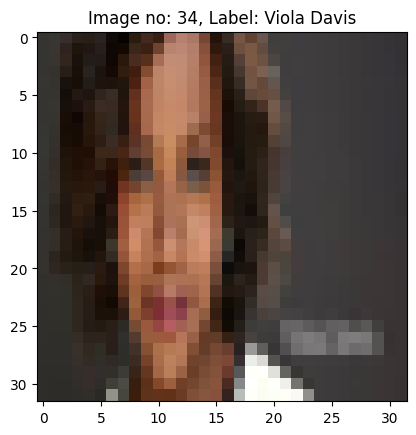

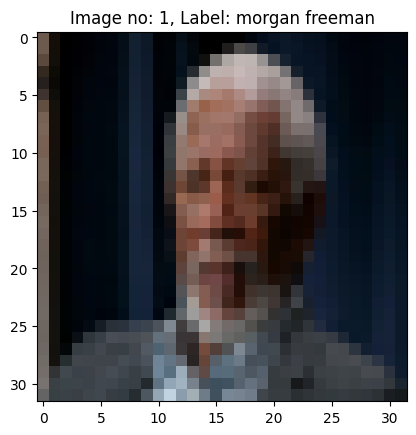

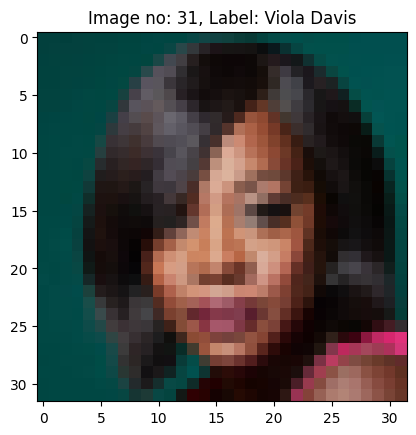


As per majority voting scheme for k=5, test image mostly resembles:  morgan freeman


In [45]:
# 5NN Code

sort_dist=np.sort(dist.flatten())
N5 = sort_dist[:5]
pos5 = [[] for _ in range (5)]
for i in range(5):
  print(i+1,"Minimum distance: ",N5[i])
  pos5[i] = np.where(dist==N5[i])
pos5=[pos5[i][1][0] for i in range(5)]

for i in range (5):
  plt.title("Image no: " + str(pos5[i]) + ", Label: " + str(label[pos5[i]][0][0]))
  plt.imshow(im[:,:,:,pos5[i]])
  plt.show()

majority_label_5nn = knn(pos5, 5)
majority_label_5nn = majority_label_5nn.strip("[]'\"")
print("\nAs per majority voting scheme for k=5, test image mostly resembles: ", majority_label_5nn)
